Original Dataset Shape: (4240, 16)

First 5 Rows:
   male  age  education  currentSmoker  cigsPerDay  BPMeds  prevalentStroke  \
0     1   39        4.0              0         0.0     0.0                0   
1     0   46        2.0              0         0.0     0.0                0   
2     1   48        1.0              1        20.0     0.0                0   
3     0   61        3.0              1        30.0     0.0                0   
4     0   46        3.0              1        23.0     0.0                0   

   prevalentHyp  diabetes  totChol  sysBP  diaBP    BMI  heartRate  glucose  \
0             0         0    195.0  106.0   70.0  26.97       80.0     77.0   
1             0         0    250.0  121.0   81.0  28.73       95.0     76.0   
2             0         0    245.0  127.5   80.0  25.34       75.0     70.0   
3             1         0    225.0  150.0   95.0  28.58       65.0    103.0   
4             0         0    285.0  130.0   84.0  23.10       85.0     85.0   



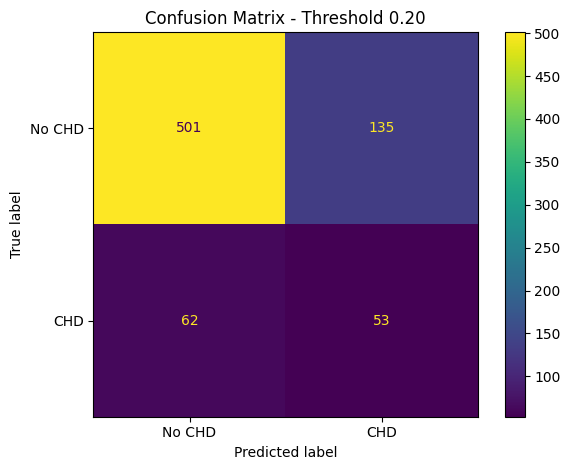

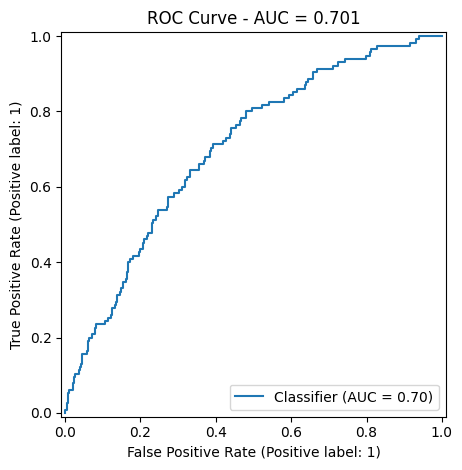

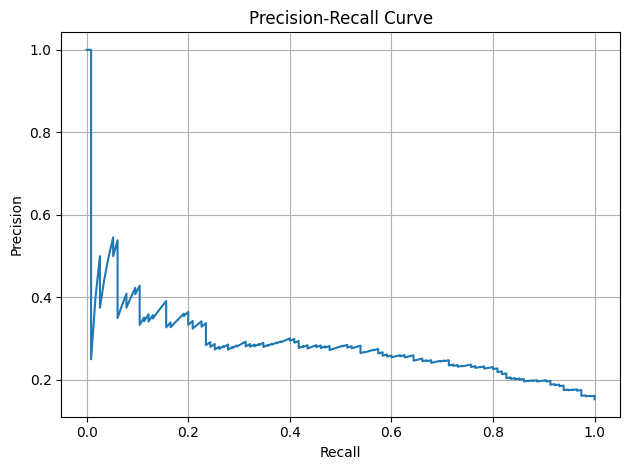

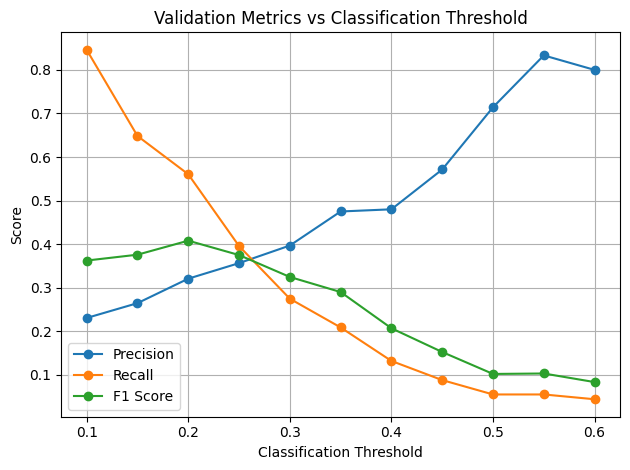


FEATURE SELECTION
Selected number of features: all
The best model retained all available features.

FINAL MODEL SUMMARY

Dataset:
Framingham Heart Disease Dataset

Original samples:
4240

Samples after cleaning:
3751

Features used:
14

Target:
TenYearCHD

Model:
Logistic Regression

Class imbalance:
Present (84.75% class 0, 15.25% class 1)

Class weighting:
Evaluated during hyperparameter tuning;
best model selected class_weight=None

Feature selection:
all

Regularization parameter C:
0.1

Solver:
lbfgs

Cross-validation:
5-fold Stratified Cross-Validation

Best CV ROC-AUC:
0.7373

Validation-selected threshold:
0.20

Final Test Accuracy:
0.7377

Final Test Precision:
0.2819

Final Test Recall:
0.4609

Final Test F1:
0.3498

Final Test ROC-AUC:
0.7007


MODEL INTERPRETATION

The dataset contains an imbalanced target, with substantially
more negative cases than positive heart-disease cases.

Therefore, model performance was evaluated using precision,
recall, F1-score and ROC-AUC in a

In [1]:
# ============================================================
# HEART DISEASE PREDICTION - FRAMINGHAM DATASET
# Final Internship-Ready ML Implementation
# ============================================================

# ------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    precision_recall_curve
)


# ------------------------------------------------------------
# 2. LOAD DATASET
# ------------------------------------------------------------

df = pd.read_csv("/content/sample_data/framingham.csv")

print("Original Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())


# ------------------------------------------------------------
# 3. DATA CLEANING
# ------------------------------------------------------------

# Education is excluded from this implementation
if "education" in df.columns:
    df = df.drop(columns=["education"])

# Remove rows containing missing values
df = df.dropna().reset_index(drop=True)

print("\nDataset Shape After Cleaning:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())


# ------------------------------------------------------------
# 4. SEPARATE FEATURES AND TARGET
# ------------------------------------------------------------

target = "TenYearCHD"

X = df.drop(columns=[target])
y = df[target]

print("\nNumber of Features:", X.shape[1])

print("\nFeature Names:")
print(X.columns.tolist())

print("\nTarget Class Distribution:")
print(y.value_counts())

print("\nTarget Class Percentage:")
print(
    y.value_counts(normalize=True).mul(100).round(2)
)


# ------------------------------------------------------------
# 5. HOLD OUT FINAL TEST SET
# ------------------------------------------------------------
# The test set is kept completely untouched until the
# final evaluation.

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Samples:", X_train_full.shape[0])
print("Testing Samples :", X_test.shape[0])


# ------------------------------------------------------------
# 6. CREATE VALIDATION SET
# ------------------------------------------------------------
# This validation set will be used ONLY for selecting the
# final probability threshold.
#
# The final test set remains untouched.

X_train, X_validation, y_train, y_validation = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=42,
    stratify=y_train_full
)

print("\nModel Training Samples :", X_train.shape[0])
print("Threshold Validation Samples:", X_validation.shape[0])


# ------------------------------------------------------------
# 7. CREATE MACHINE LEARNING PIPELINE
# ------------------------------------------------------------

pipeline = Pipeline([

    # Feature selection
    (
        "feature_selection",
        SelectKBest(
            score_func=f_classif,
            k="all"
        )
    ),

    # Standardization
    (
        "scaler",
        StandardScaler()
    ),

    # Logistic Regression
    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            random_state=42
        )
    )
])


# ------------------------------------------------------------
# 8. STRATIFIED CROSS-VALIDATION
# ------------------------------------------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_auc = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

print("\n==============================================")
print("5-FOLD STRATIFIED CROSS-VALIDATION")
print("==============================================")

print("ROC-AUC Scores:")

for i, score in enumerate(cv_auc, start=1):
    print(f"Fold {i}: {score:.4f}")

print(
    f"\nMean ROC-AUC: {cv_auc.mean():.4f}"
)

print(
    f"Standard Deviation: {cv_auc.std():.4f}"
)


# ------------------------------------------------------------
# 9. HYPERPARAMETER TUNING
# ------------------------------------------------------------

parameter_grid = {

    # Number of selected features
    "feature_selection__k": [
        "all",
        5,
        7,
        9
    ],

    # Regularization parameter
    "classifier__C": [
        0.01,
        0.1,
        1,
        10,
        100
    ],

    # Logistic Regression solver
    "classifier__solver": [
        "liblinear",
        "lbfgs"
    ],

    # Handle class imbalance
    "classifier__class_weight": [
        None,
        "balanced"
    ]
}


grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=parameter_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(
    X_train,
    y_train
)


# ------------------------------------------------------------
# 10. BEST MODEL
# ------------------------------------------------------------

best_model = grid_search.best_estimator_

print("\n==============================================")
print("HYPERPARAMETER TUNING")
print("==============================================")

print("\nBest Parameters:")

for parameter, value in grid_search.best_params_.items():
    print(f"{parameter}: {value}")

print(
    f"\nBest Cross-Validation ROC-AUC: "
    f"{grid_search.best_score_:.4f}"
)


# ------------------------------------------------------------
# 11. VALIDATION SET - GET PROBABILITIES
# ------------------------------------------------------------
# IMPORTANT:
# We use validation data to choose the classification
# threshold instead of using the final test set.

validation_probability = best_model.predict_proba(
    X_validation
)[:, 1]


# ------------------------------------------------------------
# 12. THRESHOLD ANALYSIS ON VALIDATION SET
# ------------------------------------------------------------

thresholds = np.arange(
    0.10,
    0.61,
    0.05
)

threshold_results = []

for threshold in thresholds:

    validation_prediction = (
        validation_probability >= threshold
    ).astype(int)

    precision = precision_score(
        y_validation,
        validation_prediction,
        zero_division=0
    )

    recall = recall_score(
        y_validation,
        validation_prediction,
        zero_division=0
    )

    f1 = f1_score(
        y_validation,
        validation_prediction,
        zero_division=0
    )

    accuracy = accuracy_score(
        y_validation,
        validation_prediction
    )

    threshold_results.append({

        "Threshold": round(threshold, 2),

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1": f1
    })


threshold_df = pd.DataFrame(
    threshold_results
)

print("\n==============================================")
print("VALIDATION THRESHOLD ANALYSIS")
print("==============================================")

print(
    threshold_df.to_string(index=False)
)


# ------------------------------------------------------------
# 13. SELECT BEST THRESHOLD
# ------------------------------------------------------------
# F1 is used here because it balances precision and recall.

best_threshold_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

best_threshold = float(
    best_threshold_row["Threshold"]
)

print(
    f"\nSelected Threshold Based on Validation F1: "
    f"{best_threshold:.2f}"
)


# ------------------------------------------------------------
# 14. RETRAIN BEST MODEL ON ALL TRAINING DATA
# ------------------------------------------------------------
# The validation set has served its purpose:
# selecting the threshold.
#
# We can now train the selected model on the complete
# training portion before touching the test set.

final_model = grid_search.best_estimator_

final_model.fit(
    X_train_full,
    y_train_full
)


# ------------------------------------------------------------
# 15. FINAL TEST PREDICTIONS
# ------------------------------------------------------------

test_probability = final_model.predict_proba(
    X_test
)[:, 1]

# Apply threshold selected from validation data
test_prediction = (
    test_probability >= best_threshold
).astype(int)


# ------------------------------------------------------------
# 16. FINAL TEST EVALUATION
# ------------------------------------------------------------

accuracy = accuracy_score(
    y_test,
    test_prediction
)

precision = precision_score(
    y_test,
    test_prediction,
    zero_division=0
)

recall = recall_score(
    y_test,
    test_prediction,
    zero_division=0
)

f1 = f1_score(
    y_test,
    test_prediction,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    test_probability
)


print("\n==============================================")
print("FINAL TEST PERFORMANCE")
print("==============================================")

print(f"Classification Threshold: {best_threshold:.2f}")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")


# ------------------------------------------------------------
# 17. CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\n==============================================")
print("CLASSIFICATION REPORT")
print("==============================================")

print(
    classification_report(
        y_test,
        test_prediction,
        target_names=[
            "No Heart Disease",
            "Heart Disease"
        ],
        zero_division=0
    )
)


# ------------------------------------------------------------
# 18. CONFUSION MATRIX
# ------------------------------------------------------------

cm = confusion_matrix(
    y_test,
    test_prediction
)

print("\n==============================================")
print("CONFUSION MATRIX")
print("==============================================")

print(cm)

print("\nTrue Negatives :", cm[0, 0])
print("False Positives:", cm[0, 1])
print("False Negatives:", cm[1, 0])
print("True Positives :", cm[1, 1])


ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "No CHD",
        "CHD"
    ]
).plot()

plt.title(
    f"Confusion Matrix - Threshold {best_threshold:.2f}"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 19. ROC CURVE
# ------------------------------------------------------------

RocCurveDisplay.from_predictions(
    y_test,
    test_probability
)

plt.title(
    f"ROC Curve - AUC = {roc_auc:.3f}"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 20. PRECISION-RECALL / THRESHOLD CURVE
# ------------------------------------------------------------

precision_curve, recall_curve, pr_thresholds = (
    precision_recall_curve(
        y_test,
        test_probability
    )
)

plt.figure()

plt.plot(
    recall_curve,
    precision_curve
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Precision-Recall Curve"
)

plt.grid(True)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 21. THRESHOLD METRICS VISUALIZATION
# ------------------------------------------------------------

plt.figure()

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")

plt.title(
    "Validation Metrics vs Classification Threshold"
)

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 22. FEATURE SELECTION RESULT
# ------------------------------------------------------------

selected_k = grid_search.best_params_[
    "feature_selection__k"
]

print("\n==============================================")
print("FEATURE SELECTION")
print("==============================================")

print(
    "Selected number of features:",
    selected_k
)

if selected_k == "all":

    print(
        "The best model retained all available features."
    )

else:

    selector = final_model.named_steps[
        "feature_selection"
    ]

    selected_features = X.columns[
        selector.get_support()
    ]

    print("\nSelected Features:")
    print(
        selected_features.tolist()
    )


# ------------------------------------------------------------
# 23. FINAL MODEL SUMMARY
# ------------------------------------------------------------

print("\n==============================================")
print("FINAL MODEL SUMMARY")
print("==============================================")

print(
    f"""
Dataset:
Framingham Heart Disease Dataset

Original samples:
4240

Samples after cleaning:
{len(df)}

Features used:
{X.shape[1]}

Target:
TenYearCHD

Model:
Logistic Regression

Class imbalance:
Present (84.75% class 0, 15.25% class 1)

Class weighting:
Evaluated during hyperparameter tuning;
best model selected class_weight=None

Feature selection:
{selected_k}

Regularization parameter C:
{grid_search.best_params_["classifier__C"]}

Solver:
{grid_search.best_params_["classifier__solver"]}

Cross-validation:
5-fold Stratified Cross-Validation

Best CV ROC-AUC:
{grid_search.best_score_:.4f}

Validation-selected threshold:
{best_threshold:.2f}

Final Test Accuracy:
{accuracy:.4f}

Final Test Precision:
{precision:.4f}

Final Test Recall:
{recall:.4f}

Final Test F1:
{f1:.4f}

Final Test ROC-AUC:
{roc_auc:.4f}
"""
)


# ------------------------------------------------------------
# 24. INTERPRETATION
# ------------------------------------------------------------

print("\n==============================================")
print("MODEL INTERPRETATION")
print("==============================================")

print(
    """
The dataset contains an imbalanced target, with substantially
more negative cases than positive heart-disease cases.

Therefore, model performance was evaluated using precision,
recall, F1-score and ROC-AUC in addition to accuracy.

Class weighting was included as a hyperparameter during
model tuning to determine whether it improved performance
on the imbalanced dataset. The best model ultimately
selected class_weight=None.

The classification threshold was selected using a separate
validation set rather than the final test set.

The final test set was kept unseen during threshold selection
and was used only for final performance evaluation.

The model should be considered an educational machine-learning
model and not a clinical diagnostic system.
"""
)